
Scorecard Comparison Analysis

Scorecard 1:
Maximum Score: 800
Minimum PD: 0.0000
Minimum Odds: 1638400.00

Scorecard 2:
Maximum Score: 900
Minimum PD: 0.0000
Minimum Odds: 52428800.00

Comparison:
Riskier Scorecard: Scorecard 1
PD Difference: 0.0000
Relative Risk: 32.00


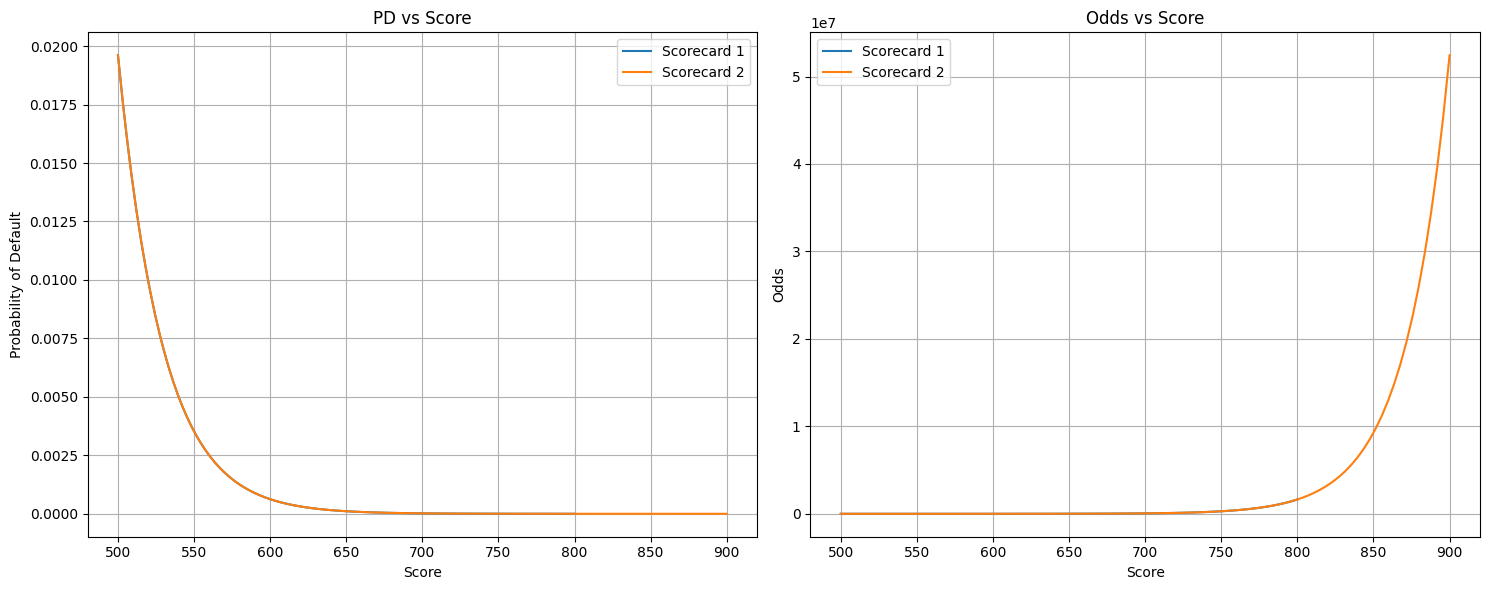


Risk Implications:
--------------------------------------------------

Approval Rate Impact:
Higher Max Score: 900
Lower Risk Scorecard: Scorecard 1
Pd Difference Bps: 0.005912777040068705

Business Implications:
Risk Appetite: Higher
Approval Threshold Adjustment: 100
Relative Risk Level: 31.99998107911307


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

class ScorecardAnalysis:
    def __init__(self, pdo=20, baseline_score=200, baseline_odds=50):
        """
        Initialize scorecard analysis
        
        Parameters:
        pdo: Points to Double the Odds (default: 20)
        baseline_score: Base score (default: 200)
        baseline_odds: Base odds (default: 50)
        """
        self.pdo = pdo
        self.baseline_score = baseline_score
        self.baseline_odds = baseline_odds
        self.factor = pdo / np.log(2)
        self.offset = baseline_score - self.factor * np.log(baseline_odds)
        
    def analyze_scorecards(self, max_scores):
        """
        Analyze multiple scorecards with different maximum scores
        """
        results = {}
        for max_score in max_scores:
            results[max_score] = self.analyze_single_scorecard(max_score)
        
        return pd.DataFrame(results).T
    
    def analyze_single_scorecard(self, max_score):
        """Analyze a single scorecard"""
        min_odds = self.calculate_odds(max_score)
        min_pd = 1 / (1 + min_odds)
        
        return {
            'Max Score': max_score,
            'Min Odds': min_odds,
            'Min PD': min_pd,
            'Score Range': max_score - self.baseline_score,
            'Log Odds Range': np.log(min_odds) - np.log(self.baseline_odds)
        }
    
    def calculate_odds(self, score):
        """Calculate odds for a given score"""
        return np.exp((score - self.offset) / self.factor)
    
    def calculate_pd(self, score):
        """Calculate PD for a given score"""
        odds = self.calculate_odds(score)
        return 1 / (1 + odds)
    
    def plot_comparison(self, max_scores):
        """Plot comparison of multiple scorecards"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        
        # Generate score ranges for each scorecard
        score_ranges = {
            max_score: np.linspace(self.baseline_score, max_score, 100)
            for max_score in max_scores
        }
        
        # Plot PD curves
        for max_score in max_scores:
            scores = score_ranges[max_score]
            pds = [self.calculate_pd(score) for score in scores]
            axes[0,0].plot(scores, pds, label=f'Max Score {max_score}')
        
        axes[0,0].set_title('PD vs Score')
        axes[0,0].set_xlabel('Score')
        axes[0,0].set_ylabel('Probability of Default')
        axes[0,0].legend()
        axes[0,0].grid(True)
        
        # Plot odds curves
        for max_score in max_scores:
            scores = score_ranges[max_score]
            odds = [self.calculate_odds(score) for score in scores]
            axes[0,1].plot(scores, odds, label=f'Max Score {max_score}')
        
        axes[0,1].set_title('Odds vs Score')
        axes[0,1].set_xlabel('Score')
        axes[0,1].set_ylabel('Odds')
        axes[0,1].legend()
        axes[0,1].grid(True)
        
        # Plot log odds
        for max_score in max_scores:
            scores = score_ranges[max_score]
            log_odds = [np.log(self.calculate_odds(score)) for score in scores]
            axes[1,0].plot(scores, log_odds, label=f'Max Score {max_score}')
        
        axes[1,0].set_title('Log Odds vs Score')
        axes[1,0].set_xlabel('Score')
        axes[1,0].set_ylabel('Log Odds')
        axes[1,0].legend()
        axes[1,0].grid(True)
        
        # Plot PD distribution
        pd_distributions = []
        for max_score in max_scores:
            scores = score_ranges[max_score]
            pds = [self.calculate_pd(score) for score in scores]
            pd_distributions.extend(pds)
        
        sns.histplot(pd_distributions, ax=axes[1,1])
        axes[1,1].set_title('PD Distribution')
        axes[1,1].set_xlabel('Probability of Default')
        axes[1,1].set_ylabel('Count')
        
        plt.tight_layout()
        return fig

def demonstrate_analysis():
    """Run comprehensive scorecard analysis"""
    # Initialize with PDO 1:20 and baseline score 200
    analyzer = ScorecardAnalysis(pdo=20, baseline_score=200, baseline_odds=50)
    
    # Compare different maximum scores
    max_scores = [400, 500, 600]
    results = analyzer.analyze_scorecards(max_scores)
    
    # Display results
    print("\nScorecard Analysis Results:")
    print("=" * 50)
    print(results.round(4))
    
    # Calculate relative risk between scorecards
    print("\nRelative Risk Analysis:")
    print("=" * 50)
    for i in range(len(max_scores)):
        for j in range(i+1, len(max_scores)):
            score1 = max_scores[i]
            score2 = max_scores[j]
            relative_risk = results.loc[score1, 'Min PD'] / results.loc[score2, 'Min PD']
            print(f"Scorecard {score1} vs {score2}:")
            print(f"Relative Risk: {relative_risk:.4f}")
            print(f"PD Difference (bps): {(results.loc[score1, 'Min PD'] - results.loc[score2, 'Min PD'])*10000:.2f}")
            print()
    
    # Plot comparisons
    fig = analyzer.plot_comparison(max_scores)
    plt.show()
    
    return results

# Run demonstration
results = demonstrate_analysis()

# Additional analysis for risk assessment
def analyze_risk_levels(results):
    """Analyze risk levels and implications"""
    risk_levels = pd.DataFrame({
        'Score Range': results['Score Range'],
        'Risk Level': pd.qcut(results['Min PD'], q=3, labels=['Low', 'Medium', 'High']),
        'PD Range (bps)': results['Min PD'] * 10000,
        'Odds Range': results['Min Odds']
    })
    
    print("\nRisk Level Analysis:")
    print("=" * 50)
    print(risk_levels)
    
    return risk_levels

risk_analysis = analyze_risk_levels(results)

def calculate_cutoff_recommendations(results):
    """Calculate recommended cutoff scores for different risk appetites"""
    recommendations = {}
    
    for max_score in results.index:
        pd_range = np.linspace(results.loc[max_score, 'Min PD'], 
                              1/(1+50), 100)  # From min PD to baseline PD
        
        recommendations[max_score] = {
            'conservative': {
                'pd_threshold': np.percentile(pd_range, 25),
                'score_threshold': results.loc[max_score, 'Max Score'] * 0.8
            },
            'moderate': {
                'pd_threshold': np.percentile(pd_range, 50),
                'score_threshold': results.loc[max_score, 'Max Score'] * 0.6
            },
            'aggressive': {
                'pd_threshold': np.percentile(pd_range, 75),
                'score_threshold': results.loc[max_score, 'Max Score'] * 0.4
            }
        }
    
    return pd.DataFrame(recommendations)

cutoff_recommendations = calculate_cutoff_recommendations(results)
print("\nCutoff Score Recommendations:")
print("=" * 50)
print(cutoff_recommendations.round(2))